In [310]:
# %pip install pandas numpy matplotlib

In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../dataset/raw.csv')
display(df)

,patient_id,age,gender,race,marital_status,insurance_type,admission_type,admission_source,length_of_stay,department,...,discharge_o2_saturation,hemoglobin_level,wbc_count,creatinine_level,glucose_level,discharge_disposition,follow_up_scheduled,medication_adherence_score,discharge_date,readmitted_30days
0,PAT_00000001,66,Male,Caucasian,Single,Medicare,Elective,Transfer,2,Pulmonology,...,97.0,10.6,9.4,2.19,122.0,Home with Home Health,Yes,9.0,2023-11-24,Yes
1,PAT_00000002,55,Male,Caucasian,Single,Self-pay,Emergency,Physician Referral,1,Cardiology,...,100.0,12.2,9.9,1.01,151.0,Home with Home Health,Yes,7.0,2023-09-07,No
2,PAT_00000003,69,Female,African American,Single,Medicare,Elective,Physician Referral,1,Orthopedics,...,96.0,14.0,2.6,0.96,108.0,Home,No,7.0,2023-06-02,Yes
3,PAT_00000004,85,Female,Asian,Divorced,Self-pay,Emergency,ER,7,Neurology,...,93.0,12.5,3.6,2.91,164.0,Home,Yes,9.0,2023-01-05,Yes
4,PAT_00000005,53,Female,African American,Married,Medicare,Emergency,Physician Referral,1,Cardiology,...,98.0,9.9,11.7,2.19,139.0,Home with Home Health,Yes,7.0,2023-10-25,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,PAT_00014996,41,Female,Asian,Single,Medicaid,Emergency,ER,3,General Medicine,...,98.0,13.5,8.5,0.43,81.0,Home with Home Health,Yes,10.0,2023-06-09,No
14996,PAT_00014997,80,Female,Hispanic,Married,Medicare,Elective,Clinic,9,Orthopedics,...,90.0,9.3,15.4,0.03,91.0,Skilled Nursing Facility,Yes,6.0,2023-12-28,No
14997,PAT_00014998,81,Female,Caucasian,Single,Private,Emergency,ER,6,Orthopedics,...,95.0,10.0,6.7,0.37,100.0,Rehab,No,5.0,2023-08-22,No
14998,PAT_00014999,42,Male,Hispanic,Divorced,Medicare,Elective,ER,2,General Medicine,...,95.0,14.1,10.2,0.00,4.0,Home,Yes,6.0,2023-06-30,Yes


Get Cols

In [312]:
cols  = df.columns
print(cols)

Index(['patient_id', 'age', 'gender', 'race', 'marital_status',
       'insurance_type', 'admission_type', 'admission_source',
       'length_of_stay', 'department', 'room_type', 'num_procedures',
       'num_medications', 'has_diabetes', 'has_hypertension',
       'has_heart_disease', 'has_copd', 'has_kidney_disease',
       'previous_admissions', 'discharge_systolic_bp',
       'discharge_diastolic_bp', 'discharge_heart_rate',
       'discharge_temperature', 'discharge_o2_saturation', 'hemoglobin_level',
       'wbc_count', 'creatinine_level', 'glucose_level',
       'discharge_disposition', 'follow_up_scheduled',
       'medication_adherence_score', 'discharge_date', 'readmitted_30days'],
      dtype='object')


In [313]:
print(df.shape)



(15000, 33)


In [314]:
print(df.size)

495000


In [315]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   patient_id                  15000 non-null  object 
 1   age                         15000 non-null  int64  
 2   gender                      15000 non-null  object 
 3   race                        15000 non-null  object 
 4   marital_status              15000 non-null  object 
 5   insurance_type              15000 non-null  object 
 6   admission_type              15000 non-null  object 
 7   admission_source            15000 non-null  object 
 8   length_of_stay              15000 non-null  int64  
 9   department                  15000 non-null  object 
 10  room_type                   15000 non-null  object 
 11  num_procedures              15000 non-null  int64  
 12  num_medications             15000 non-null  int64  
 13  has_diabetes                150

In [316]:
df.describe()

,age,length_of_stay,num_procedures,num_medications,previous_admissions,discharge_systolic_bp,discharge_diastolic_bp,discharge_heart_rate,discharge_temperature,discharge_o2_saturation,hemoglobin_level,wbc_count,creatinine_level,glucose_level,medication_adherence_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14400.000000,14400.000000,14400.000000,15000.000000,15000.000000,14400.000000
mean,57.509733,4.168933,2.509867,8.023200,1.499400,124.905600,77.633600,77.468600,98.390620,95.428681,12.490049,7.939451,1.194018,119.867867,6.934722
std,17.475312,4.232303,1.575627,2.808722,1.221897,17.480915,11.905741,11.906091,0.805084,2.874662,1.998187,2.975913,1.194558,40.233667,1.905151
min,18.000000,1.000000,0.000000,1.000000,0.000000,90.000000,50.000000,50.000000,95.100000,85.000000,4.800000,-6.500000,0.000000,-28.000000,1.000000
25%,45.000000,1.000000,1.000000,6.000000,1.000000,113.000000,69.000000,69.000000,97.800000,93.000000,11.100000,5.900000,0.340000,92.000000,6.000000
50%,58.000000,3.000000,2.000000,8.000000,1.000000,125.000000,78.000000,77.000000,98.400000,96.000000,12.500000,7.900000,0.830000,120.000000,7.000000
75%,70.000000,6.000000,3.000000,10.000000,2.000000,137.000000,86.000000,86.000000,98.900000,98.000000,13.900000,9.900000,1.660000,147.000000,8.000000
max,95.000000,30.000000,11.000000,26.000000,9.000000,192.000000,120.000000,121.000000,101.800000,100.000000,19.400000,19.700000,10.840000,281.000000,10.000000


In [317]:
null_cols = df.isnull().sum()
print(null_cols[null_cols > 0])

discharge_o2_saturation       600
hemoglobin_level              600
wbc_count                     600
medication_adherence_score    600
dtype: int64


In [318]:
duplicates = df[df.duplicated()]
display(duplicates)

,patient_id,age,gender,race,marital_status,insurance_type,admission_type,admission_source,length_of_stay,department,...,discharge_o2_saturation,hemoglobin_level,wbc_count,creatinine_level,glucose_level,discharge_disposition,follow_up_scheduled,medication_adherence_score,discharge_date,readmitted_30days


In [319]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# corr = df.corr()
# sns.heatmap(corr, annot=True, cmap='coolwarm')
# plt.show()

In [320]:
print("=== Datatypes ===")
print(df.dtypes)

numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns



=== Datatypes ===
patient_id                     object
age                             int64
gender                         object
race                           object
marital_status                 object
insurance_type                 object
admission_type                 object
admission_source               object
length_of_stay                  int64
department                     object
room_type                      object
num_procedures                  int64
num_medications                 int64
has_diabetes                   object
has_hypertension               object
has_heart_disease              object
has_copd                       object
has_kidney_disease             object
previous_admissions             int64
discharge_systolic_bp           int64
discharge_diastolic_bp          int64
discharge_heart_rate            int64
discharge_temperature         float64
discharge_o2_saturation       float64
hemoglobin_level              float64
wbc_count                     fl

In [321]:
print("\n=== Numeric Columns ===")
print(list(numeric_cols))




=== Numeric Columns ===
['age', 'length_of_stay', 'num_procedures', 'num_medications', 'previous_admissions', 'discharge_systolic_bp', 'discharge_diastolic_bp', 'discharge_heart_rate', 'discharge_temperature', 'discharge_o2_saturation', 'hemoglobin_level', 'wbc_count', 'creatinine_level', 'glucose_level', 'medication_adherence_score']


In [322]:
print("\n=== Categorical Columns ===")
print(list(categorical_cols))


=== Categorical Columns ===
['patient_id', 'gender', 'race', 'marital_status', 'insurance_type', 'admission_type', 'admission_source', 'department', 'room_type', 'has_diabetes', 'has_hypertension', 'has_heart_disease', 'has_copd', 'has_kidney_disease', 'discharge_disposition', 'follow_up_scheduled', 'discharge_date', 'readmitted_30days']


In [323]:
import pandas as pd



# Columns to remove
cols_to_drop = [
    "patient_id",
    "gender",
    "race",
    "marital_status",
    "discharge_date"
]

# Drop columns
df_clean = df.drop(columns=cols_to_drop)

# Save new dataset
df_clean.to_csv("../dataset/base_raw.csv", index=False)

print("Columns removed and saved as base_raw.csv")

Columns removed and saved as base_raw.csv


In [324]:
df = pd.read_csv("../dataset/base_raw.csv")

df.isnull().sum()

age                             0
insurance_type                  0
admission_type                  0
admission_source                0
length_of_stay                  0
department                      0
room_type                       0
num_procedures                  0
num_medications                 0
has_diabetes                    0
has_hypertension                0
has_heart_disease               0
has_copd                        0
has_kidney_disease              0
previous_admissions             0
discharge_systolic_bp           0
discharge_diastolic_bp          0
discharge_heart_rate            0
discharge_temperature           0
discharge_o2_saturation       600
hemoglobin_level              600
wbc_count                     600
creatinine_level                0
glucose_level                   0
discharge_disposition           0
follow_up_scheduled             0
medication_adherence_score    600
readmitted_30days               0
dtype: int64

In [325]:
df.duplicated().sum()

0

In [326]:
df.describe()

,age,length_of_stay,num_procedures,num_medications,previous_admissions,discharge_systolic_bp,discharge_diastolic_bp,discharge_heart_rate,discharge_temperature,discharge_o2_saturation,hemoglobin_level,wbc_count,creatinine_level,glucose_level,medication_adherence_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14400.000000,14400.000000,14400.000000,15000.000000,15000.000000,14400.000000
mean,57.509733,4.168933,2.509867,8.023200,1.499400,124.905600,77.633600,77.468600,98.390620,95.428681,12.490049,7.939451,1.194018,119.867867,6.934722
std,17.475312,4.232303,1.575627,2.808722,1.221897,17.480915,11.905741,11.906091,0.805084,2.874662,1.998187,2.975913,1.194558,40.233667,1.905151
min,18.000000,1.000000,0.000000,1.000000,0.000000,90.000000,50.000000,50.000000,95.100000,85.000000,4.800000,-6.500000,0.000000,-28.000000,1.000000
25%,45.000000,1.000000,1.000000,6.000000,1.000000,113.000000,69.000000,69.000000,97.800000,93.000000,11.100000,5.900000,0.340000,92.000000,6.000000
50%,58.000000,3.000000,2.000000,8.000000,1.000000,125.000000,78.000000,77.000000,98.400000,96.000000,12.500000,7.900000,0.830000,120.000000,7.000000
75%,70.000000,6.000000,3.000000,10.000000,2.000000,137.000000,86.000000,86.000000,98.900000,98.000000,13.900000,9.900000,1.660000,147.000000,8.000000
max,95.000000,30.000000,11.000000,26.000000,9.000000,192.000000,120.000000,121.000000,101.800000,100.000000,19.400000,19.700000,10.840000,281.000000,10.000000


In [327]:
df_clean = df[
    (df['wbc_count'] > 0) &
    (df['glucose_level'] > 0) &
    (df['creatinine_level'] > 0)
].copy()

df_clean.to_csv("../dataset/base_raw.csv", index=False)

print(len(df_clean))
print(len(df))

# < 5% safe to drop

df = df_clean.copy()



14280
15000


=== Statistical Summary ===
                age  length_of_stay  num_procedures  num_medications  \
count  14280.000000    14280.000000    14280.000000     14280.000000   
mean      57.476120        4.171849        2.508193         8.019538   
std       17.473993        4.230344        1.573848         2.803402   
min       18.000000        1.000000        0.000000         1.000000   
25%       45.000000        1.000000        1.000000         6.000000   
50%       58.000000        3.000000        2.000000         8.000000   
75%       70.000000        6.000000        3.000000        10.000000   
max       95.000000       30.000000       11.000000        26.000000   

       previous_admissions  discharge_systolic_bp  discharge_diastolic_bp  \
count         14280.000000           14280.000000            14280.000000   
mean              1.496359             124.934664               77.651261   
std               1.223008              17.519827               11.906972   
min            

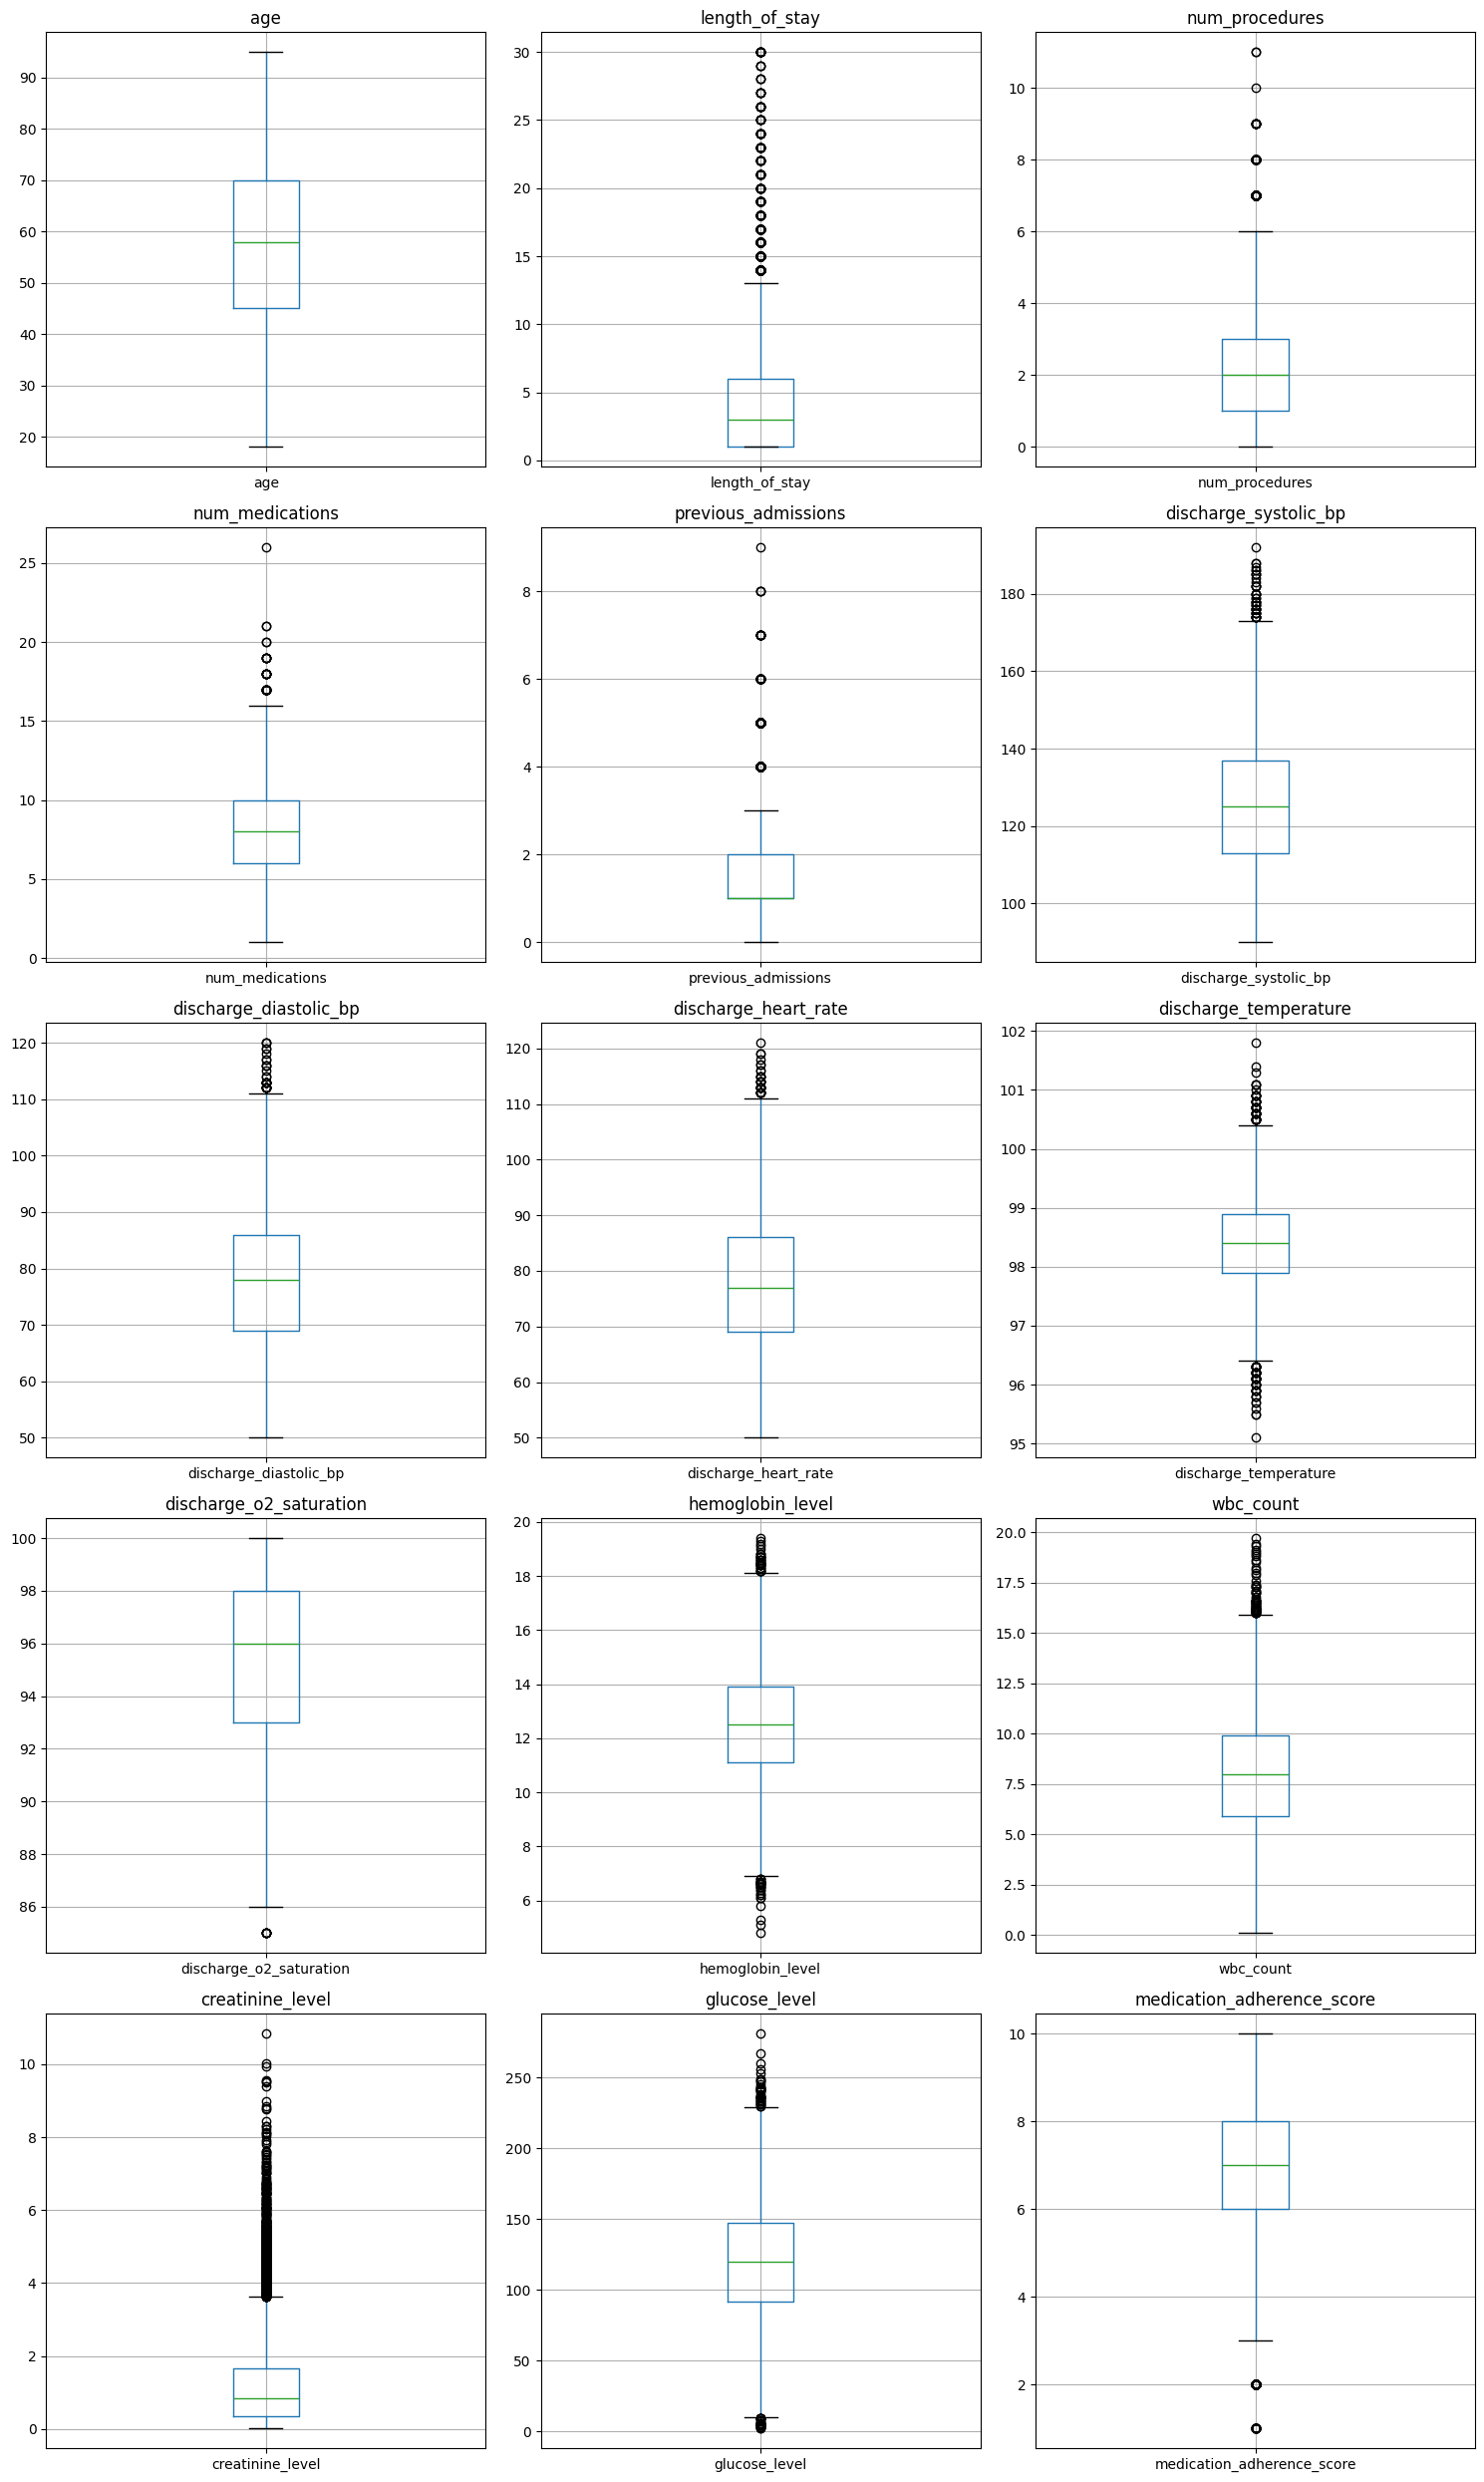

In [328]:
import matplotlib.pyplot as plt

# Describe
print("=== Statistical Summary ===")
print(df.describe())


num_cols = numeric_cols


n = len(num_cols)
rows = (n // 3) + (n % 3 > 0)  
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))

axes = axes.flatten() 

for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [329]:
# num_cols = numeric_cols

# for col in num_cols:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1

#     lower = Q1 - 1.5 * IQR
#     # lower = max(0, lower)
#     upper = Q3 + 1.5 * IQR

#     max_val = df[col].max()
#     min_val = df[col].min()

#     print(f"\nColumn: {col}")

#     print(f"IQR: {IQR}")
#     print(f"Lower Bound: {lower}")
#     print(f"Min: {min_val}")    

#     print(f"Upper Bound: {upper}")
     
    
#     print(f"Max: {max_val}")

#     outliers = df[(df[col] < lower) | (df[col] > upper)]
#     print(f"Outliers count: {len(outliers)}")

num_cols = numeric_cols

with open("outlier_report.txt", "w") as f:
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        max_val = df[col].max()
        min_val = df[col].min()

        f.write(f"\nColumn: {col}\n")
        f.write(f"IQR: {IQR}\n")
        f.write(f"Lower Bound: {lower}\n")
        f.write(f"Min: {min_val}\n")
        f.write(f"Upper Bound: {upper}\n")
        f.write(f"Max: {max_val}\n")

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        f.write(f"Outliers count: {len(outliers)}\n")

In [330]:
# M1 - means comparison of outliers vs normal data

# 1. Ensure column names are clean
df.columns = df.columns.str.strip()

# 2. Clean and convert target
df["readmitted_30days"] = (
    df["readmitted_30days"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0})
)

# Remove rows where mapping failed (if any)
df = df[df["readmitted_30days"].notna()]


# 3. Compute IQR bounds for length_of_stay
Q1 = df['length_of_stay'].quantile(0.25)
Q3 = df['length_of_stay'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


# 4. Create groups
lower_outliers = df[df['length_of_stay'] < lower]   
upper_outliers = df[df['length_of_stay'] > upper]
normal_data = df[(df['length_of_stay'] >= lower) & (df['length_of_stay'] <= upper)]


# 5. Safe mean function (handles empty groups)
def safe_mean(series):
    return round(series.mean(), 3) if len(series) > 0 else "No data"


# 6. Print counts
print("\n--- Group Sizes ---")
print(f"Lower Outliers: {len(lower_outliers)}")
print(f"Upper Outliers: {len(upper_outliers)}")
print(f"Normal Data: {len(normal_data)}")


# 7. Mean comparison (TARGET)
mean_lower = safe_mean(lower_outliers['readmitted_30days'])
mean_upper = safe_mean(upper_outliers['readmitted_30days'])
mean_normal = safe_mean(normal_data['readmitted_30days'])

print("\n--- Readmission Rates ---")
print(f"Lower Readmission Rate: {mean_lower}")
print(f"Upper Readmission Rate: {mean_upper}")
print(f"Normal Readmission Rate: {mean_normal}")


--- Group Sizes ---
Lower Outliers: 0
Upper Outliers: 596
Normal Data: 13684

--- Readmission Rates ---
Lower Readmission Rate: No data
Upper Readmission Rate: 0.349
Normal Readmission Rate: 0.253


In [331]:
# Proving the outliers in length_of_stay contributes to output 

In [332]:
# # M1 - means comparison of outliers vs normal data

# # 1. Ensure column names are clean
# df.columns = df.columns.str.strip()

# # 2. Clean and convert target
# df["readmitted_30days"] = (
#     df["readmitted_30days"]
#     .astype(str)
#     .str.strip()
#     .str.lower()
#     .map({"yes": 1, "no": 0})
# )

# # Remove rows where mapping failed (if any)
# df = df[df["readmitted_30days"].notna()]


# # 3. Compute IQR bounds for length_of_stay
# Q1 = df['length_of_stay'].quantile(0.25)
# Q3 = df['length_of_stay'].quantile(0.75)
# IQR = Q3 - Q1

# lower = Q1 - 1.5 * IQR
# upper = Q3 + 1.5 * IQR


# # 4. Create groups
# lower_outliers = df[df['length_of_stay'] < lower]   
# upper_outliers = df[df['length_of_stay'] > upper]
# normal_data = df[(df['length_of_stay'] >= lower) & (df['length_of_stay'] <= upper)]


# # 5. Safe mean function (handles empty groups)
# def safe_mean(series):
#     return round(series.mean(), 3) if len(series) > 0 else "No data"


# # 6. Print counts
# print("\n--- Group Sizes ---")
# print(f"Lower Outliers: {len(lower_outliers)}")
# print(f"Upper Outliers: {len(upper_outliers)}")
# print(f"Normal Data: {len(normal_data)}")


# # 7. Mean comparison (TARGET)
# mean_lower = safe_mean(lower_outliers['readmitted_30days'])
# mean_upper = safe_mean(upper_outliers['readmitted_30days'])
# mean_normal = safe_mean(normal_data['readmitted_30days'])

# print("\n--- Readmission Rates ---")
# print(f"Lower Readmission Rate: {mean_lower}")
# print(f"Upper Readmission Rate: {mean_upper}")
# print(f"Normal Readmission Rate: {mean_normal}")

<!-- length_of_stay has a POSITIVE relationship with readmission -->

In [333]:
from scipy.stats import mannwhitneyu

# Clean series
normal = normal_data['readmitted_30days']
upper = upper_outliers['readmitted_30days']

print("\n--- After Cleaning ---")
print("Normal size:", len(normal))
print("Upper size:", len(upper))

# ✅ SAFE CHECK
if len(normal) == 0 or len(upper) == 0:
    print("\n❌ Cannot perform hypothesis test")
    print("👉 One of the groups is empty after cleaning")

else:
    stat, p_value = mannwhitneyu(normal, upper, alternative='less')

    print("\n=== Hypothesis Test Result ===")
    print("P-value:", p_value)

    if p_value < 0.05:
        print("✅ Reject H0 → Significant difference")
    else:
        print("❌ Fail to reject H0 → Not significant")


--- After Cleaning ---
Normal size: 13684
Upper size: 596

=== Hypothesis Test Result ===
P-value: 7.077374348398964e-08
✅ Reject H0 → Significant difference


In [334]:
# Finally : There is a statistically significant difference in readmission rates
# between normal and high length_of_stay patients

In [335]:
from scipy.stats import mannwhitneyu
import pandas as pd

results = []

# ✅ Open file with UTF-8 (fixes emoji error)
with open("full_outlier_analysis.txt", "w", encoding="utf-8") as f:

    # Logging function
    def log(text):
        print(text)          # console
        f.write(text + "\n") # file

    for col in numeric_cols:
        
        log("\n==============================")
        log(f"Column: {col}")
        log("==============================")

        # 1. IQR calculation
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # 2. Create groups
        lower_outliers = df[df[col] < lower]
        upper_outliers = df[df[col] > upper]
        normal_data = df[(df[col] >= lower) & (df[col] <= upper)]

        # 3. Safe mean
        def safe_mean(series):
            return round(series.mean(), 3) if len(series) > 0 else "No data"

        mean_lower = safe_mean(lower_outliers['readmitted_30days'])
        mean_upper = safe_mean(upper_outliers['readmitted_30days'])
        mean_normal = safe_mean(normal_data['readmitted_30days'])

        # 4. Print group stats
        log("\n--- Group Sizes ---")
        log(f"Lower Outliers: {len(lower_outliers)}")
        log(f"Upper Outliers: {len(upper_outliers)}")
        log(f"Normal Data: {len(normal_data)}")

        log("\n--- Readmission Rates ---")
        log(f"Lower: {mean_lower}")
        log(f"Upper: {mean_upper}")
        log(f"Normal: {mean_normal}")

        # Prepare series
        normal = normal_data['readmitted_30days']
        upper_grp = upper_outliers['readmitted_30days']
        lower_grp = lower_outliers['readmitted_30days']

        # =========================
        # TEST 1: Normal vs Upper
        # =========================
        log("\n--- Test: Normal vs Upper ---")
        if len(normal) > 0 and len(upper_grp) > 0:
            stat, p1 = mannwhitneyu(normal, upper_grp, alternative='less')
            log(f"P-value: {p1}")
            log("Result: " + ("✅ Significant" if p1 < 0.05 else "❌ Not Significant"))
        else:
            p1 = None
            log("❌ Skipped (empty group)")

        # =========================
        # TEST 2: Normal vs Lower
        # =========================
        log("\n--- Test: Normal vs Lower ---")
        if len(normal) > 0 and len(lower_grp) > 0:
            stat, p2 = mannwhitneyu(lower_grp, normal, alternative='less')
            log(f"P-value: {p2}")
            log("Result: " + ("✅ Significant" if p2 < 0.05 else "❌ Not Significant"))
        else:
            p2 = None
            log("❌ Skipped (empty group)")

        # =========================
        # TEST 3: Lower vs Upper
        # =========================
        log("\n--- Test: Lower vs Upper ---")
        if len(lower_grp) > 0 and len(upper_grp) > 0:
            stat, p3 = mannwhitneyu(lower_grp, upper_grp)
            log(f"P-value: {p3}")
            log("Result: " + ("✅ Significant" if p3 < 0.05 else "❌ Not Significant"))
        else:
            p3 = None
            log("❌ Skipped (empty group)")

        # 5. Store results
        results.append({
            "feature": col,
            "p_normal_vs_upper": p1,
            "p_normal_vs_lower": p2,
            "p_lower_vs_upper": p3,
            "mean_lower": mean_lower,
            "mean_upper": mean_upper,
            "mean_normal": mean_normal
        })

# =========================
# SAVE SUMMARY CSV
# =========================
results_df = pd.DataFrame(results)

# Sort by strongest effect (lowest p-value)
results_df = results_df.sort_values(by="p_normal_vs_upper", na_position='last')

results_df.to_csv("summary_results.csv", index=False)

print("\n✅ Analysis complete!")
print("📁 File saved: full_outlier_analysis.txt")
print("📊 Summary saved: summary_results.csv")


Column: age

--- Group Sizes ---
Lower Outliers: 0
Upper Outliers: 0
Normal Data: 14280

--- Readmission Rates ---
Lower: No data
Upper: No data
Normal: 0.257

--- Test: Normal vs Upper ---
❌ Skipped (empty group)

--- Test: Normal vs Lower ---
❌ Skipped (empty group)

--- Test: Lower vs Upper ---
❌ Skipped (empty group)

Column: length_of_stay

--- Group Sizes ---
Lower Outliers: 0
Upper Outliers: 596
Normal Data: 13684

--- Readmission Rates ---
Lower: No data
Upper: 0.349
Normal: 0.253

--- Test: Normal vs Upper ---
P-value: 7.077374348398964e-08
Result: ✅ Significant

--- Test: Normal vs Lower ---
❌ Skipped (empty group)

--- Test: Lower vs Upper ---
❌ Skipped (empty group)

Column: num_procedures

--- Group Sizes ---
Lower Outliers: 0
Upper Outliers: 208
Normal Data: 14072

--- Readmission Rates ---
Lower: No data
Upper: 0.332
Normal: 0.256

--- Test: Normal vs Upper ---
P-value: 0.006350405895010957
Result: ✅ Significant

--- Test: Normal vs Lower ---
❌ Skipped (empty group)

--